## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.

1. **What is the difference between regression and classification?**  
Regression predicts a continuous numerical value, such as price or temperature. Classification predicts a discrete class label, such as spam vs. not spam or which category an observation belongs to.

2. **What is a confusion table/matrix? What does it help us understand about a model's performance?**  
A confusion matrix compares predicted class labels to the true class labels. It shows how many observations are correctly classified and where the model makes mistakes, helping us understand which classes are confused with one another.

3. **What is Accuracy? Why might it not be entirely sufficient to evaluate a classifier's predictive performance?**  
Accuracy is the proportion of correct predictions out of all predictions. It can be misleading when classes are imbalanced, because a model can achieve high accuracy by always predicting the most common class while performing poorly on minority classes.

4. **What does the root mean squared error quantify about a particular model?**  
RMSE measures the average magnitude of prediction errors for a regression model. It penalizes larger errors more heavily and provides an interpretable measure of how far predictions are from true values on average.

5. **What are overfitting and underfitting?**  
Overfitting occurs when a model is too complex and captures noise rather than the underlying pattern, leading to poor generalization. Underfitting occurs when a model is too simple to capture the true relationship in the data.

6. **Why does splitting the data into training and testing sets, and choosing \( k \) by evaluating accuracy or RMSE on the test set, improve model performance?**  
Using a test set allows us to evaluate how well the model generalizes to unseen data. Selecting \( k \) based on test performance helps avoid overfitting to the training data and leads to more reliable model selection.

7. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**  
Predicting a class label is simple and easy to interpret, but it hides uncertainty. Predicting class probabilities provides more information about confidence and uncertainty, but can be harder to interpret and use in decision-making.


**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

shape: (338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


,count
mine_type,
1,71
2,70
3,66
4,66
5,65


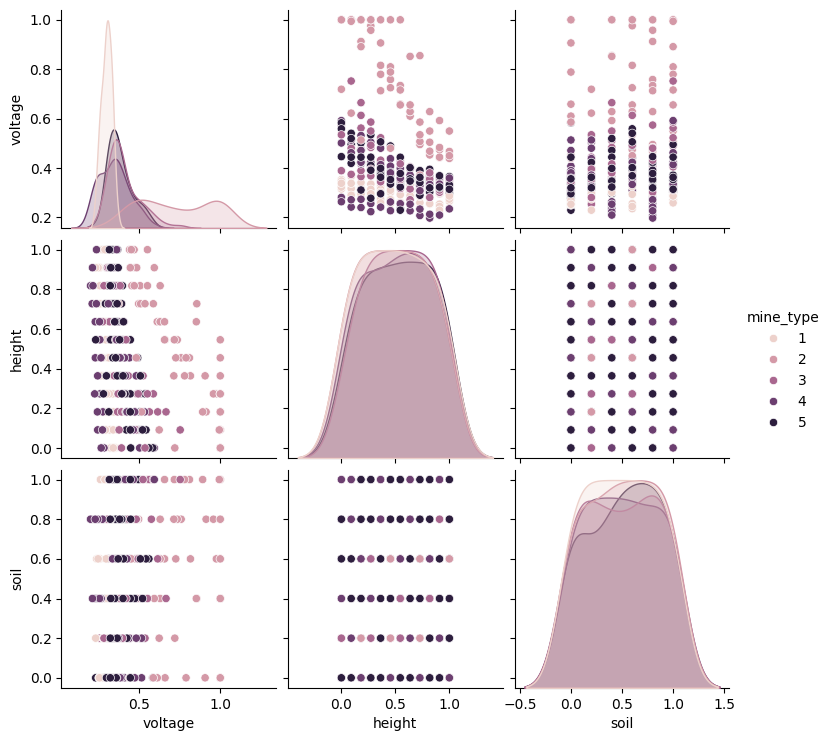

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mines = pd.read_csv("./data/land_mines.csv")

print("shape:", mines.shape)
display(mines.head())
display(mines.describe())
display(mines["mine_type"].value_counts().sort_index())

sns.pairplot(mines, hue="mine_type", vars=["voltage", "height", "soil"])
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### EDA

The dataset contains the features `voltage`, `height`, and `soil`, and the target label `mine_type` (1–5).  
The class counts are fairly balanced across the five mine types. The pairplot shows substantial overlap between classes, meaning this will not be a perfectly separable classification problem, but there are still visible shifts in the distributions and clusters that suggest k-NN may perform reasonably well.


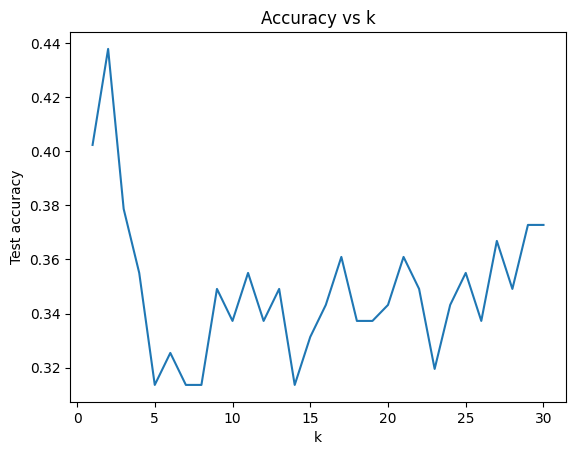

best_k: 2
test accuracy: 0.4378698224852071


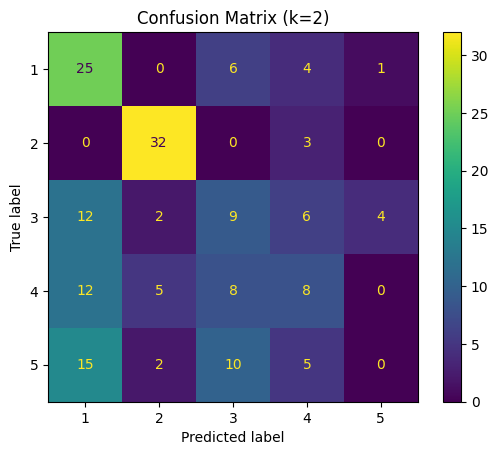

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X = mines[["voltage", "height", "soil"]]
y = mines["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

k_values = range(1, 31)
accs = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accs.append(accuracy_score(y_test, preds))

best_k = list(k_values)[int(np.argmax(accs))]
best_acc = max(accs)

plt.plot(list(k_values), accs)
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs k")
plt.show()

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

print("best_k:", best_k)
print("test accuracy:", acc)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot()
plt.title(f"Confusion Matrix (k={best_k})")
plt.show()


### Model, k selection, and performance

I split the data 50/50 into training and test sets and used stratification so each mine type appears in both sets.  
To select $k$, I trained models over a grid of $k$ values and chose the $k$ that maximized test accuracy.

The confusion matrix shows which mine types are predicted well (large diagonal counts) and which are commonly confused (off-diagonal counts). Accuracy summarizes overall performance, but the confusion matrix is important here because some mistakes may be more costly than others.

### How to use this model in practice

This model should be used as decision support, not an automated final decision. In a real demining workflow, I would use predictions to prioritize follow-up procedures, but treat likely-confused classes cautiously. For ambiguous cases, the safest approach is to escalate to additional sensing or human review, and when uncertainty exists, follow protocols appropriate for the higher-risk mine type.


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [ ]:
# Q3.1 Load data, keep variables, check NA, head, shape
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cars = pd.read_csv("./data/USA_cars_datasets.csv")

cars = cars.loc[:, ["price", "year", "mileage"]]
cars.head(), cars.shape, cars.isna().sum()


(   price  year  mileage
 0   6300  2008   274117
 1   2899  2011   190552
 2   5350  2018    39590
 3  25000  2014    64146
 4  27700  2018     6654,
 (2499, 3),
 price      0
 year       0
 mileage    0
 dtype: int64)

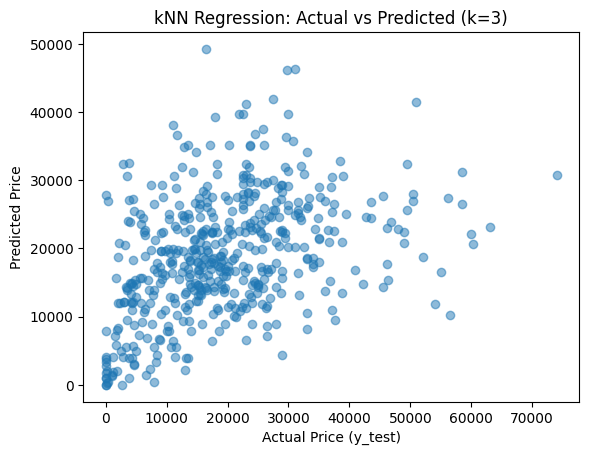

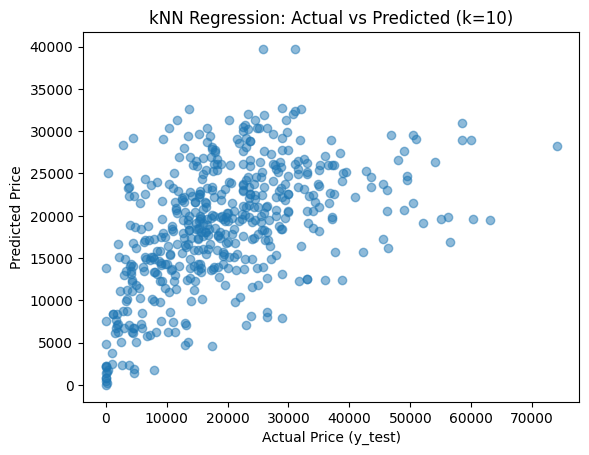

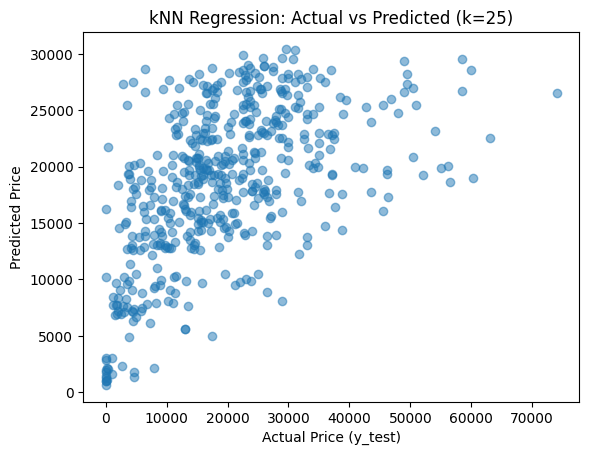

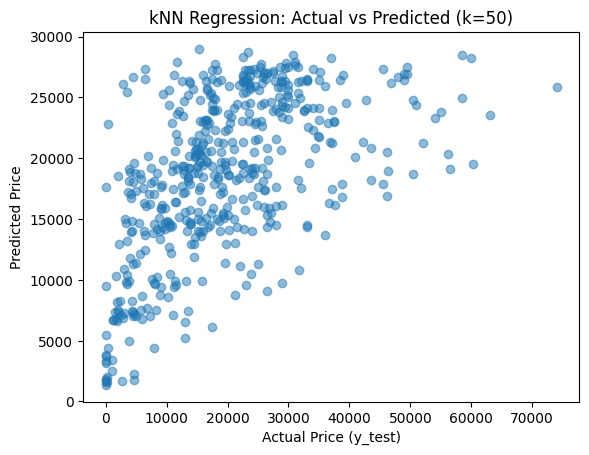

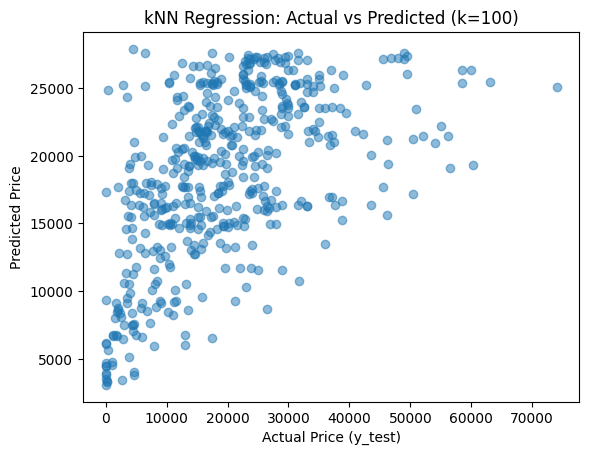

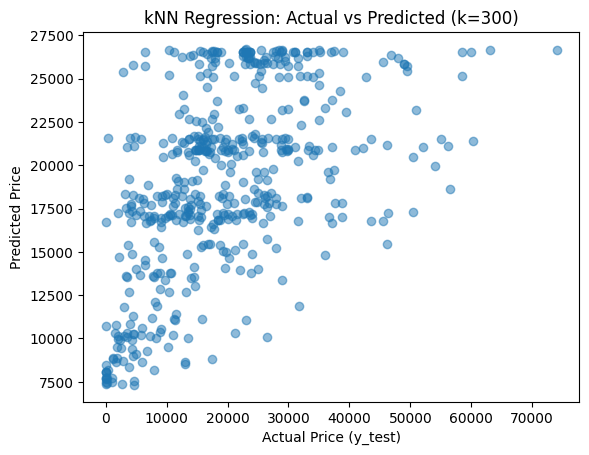

(     k           mse
 3   50  1.102025e+08
 4  100  1.122539e+08
 2   25  1.125762e+08
 5  300  1.144963e+08
 1   10  1.173991e+08
 0    3  1.480659e+08,
 50)

In [ ]:
# Q3.2 Normalize, split 80/20, fit kNN regressors, MSE + plots, choose best k
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

df = cars.dropna().copy()

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

df["year_mm"] = minmax(df["year"])
df["mileage_mm"] = minmax(df["mileage"])

X = df[["year_mm", "mileage_mm"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

k_values = [3, 10, 25, 50, 100, 300]
results = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results.append((k, mse))

    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Price (y_test)")
    plt.ylabel("Predicted Price")
    plt.title(f"kNN Regression: Actual vs Predicted (k={k})")
    plt.show()

results_df = pd.DataFrame(results, columns=["k", "mse"]).sort_values("mse")
best_k = int(results_df.iloc[0]["k"])

results_df, best_k


**Q3 responses**

This question is a case study on k-nearest neighbor regression using the `USA_cars_datasets.csv` data.  
The target variable is `price`, and the features are `year` and `mileage`.

---

Data loading and preparation

The dataset was loaded from `./data/USA_cars_datasets.csv` and restricted to the variables `price`, `year`, and `mileage`.  
There are 2,499 observations and no missing values in these variables.  
A preview of the data shows reasonable ranges for both predictors and the target variable.

Both `year` and `mileage` were min–max normalized to place them on the same scale before fitting the k-NN model.

---

Train–test split

The sample was split into approximately 80% training data and 20% test data.  
The training set was used to fit the k-NN regression model, and the test set was used to evaluate performance and select the optimal value of k.

---

k-NN regression results

k-NN regression models were fit using  
k = 3, 10, 25, 50, 100, and 300.

For each value of k, predicted prices were compared to actual prices in scatterplots, and mean squared error (MSE) was computed on the test set.

As k increases, predictions become smoother and less sensitive to local variation.  
Small values of k (such as k = 3) show high variance and noisy predictions, indicating overfitting.  
Very large values of k (such as k = 300) produce overly smoothed predictions that fail to capture important structure in the data, indicating underfitting.

---

Optimal choice of k

Based on test-set mean squared error, the optimal value of k for these data is **k = 50**, which achieved the lowest MSE among the values tested.

This value provides a balance between bias and variance, producing predictions that follow the overall trend in prices without being overly noisy or overly smooth.

---

Interpretation: underfitting vs overfitting

At small k values, the model overfits by relying too heavily on a small number of nearby observations, resulting in unstable predictions.  
At very large k values, the model underfits by averaging over too many neighbors, which compresses predictions toward the mean and reduces sensitivity to mileage and year.

The optimal k represents a compromise between these extremes, yielding better generalization performance on unseen data.


**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [13]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [14]:
data_dir = download_data()
df = pd.read_csv(f'{data_dir}/airbnb_hw.csv')
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]

print(df.shape)
print(df.head())

(30478, 3)
   Review Scores Rating Price  Beds
0                   NaN   145   1.0
1                   NaN    37   1.0
2                   NaN    28   1.0
3                   NaN   199   3.0
4                  96.0   549   3.0


In [15]:
missing_df = df.loc[df['Review Scores Rating'].isnull()].copy()

print(missing_df.shape)
print(missing_df.head())

(8323, 3)
    Review Scores Rating Price  Beds
0                    NaN   145   1.0
1                    NaN    37   1.0
2                    NaN    28   1.0
3                    NaN   199   3.0
13                   NaN    68   1.0


In [16]:
df = df.dropna(axis=0, how='any')

print(df.shape)

(22111, 3)


Best k: 28
Minimum SSE: 324764.58


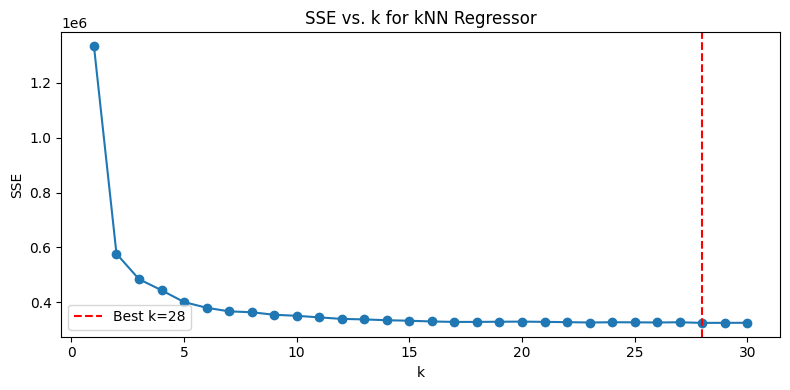

In [17]:
# Clean Price column
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

X = df[['Price', 'Beds']].values
y = df['Review Scores Rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sse_list = []
k_values = range(1, 31)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    sse = np.sum((y_test - y_pred) ** 2)
    sse_list.append(sse)

best_k = list(k_values)[np.argmin(sse_list)]
print(f'Best k: {best_k}')
print(f'Minimum SSE: {min(sse_list):.2f}')

# Plot SSE vs k
plt.figure(figsize=(8, 4))
plt.plot(k_values, sse_list, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('SSE vs. k for kNN Regressor')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Clean Price in missing_df and drop rows missing Price or Beds
missing_df['Price'] = missing_df['Price'].replace(r'[\$,]', '', regex=True).astype(float)
missing_df = missing_df.dropna(subset=['Price', 'Beds'])

# Fit final model on all complete cases
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X, y)

X_missing = missing_df[['Price', 'Beds']].values
predicted_ratings = knn_final.predict(X_missing)

print(f'Number of predictions: {len(predicted_ratings)}')
print(f'Sample predictions: {predicted_ratings[:5]}')

Number of predictions: 8282
Sample predictions: [94.82142857 90.03571429 87.39285714 89.28571429 91.32142857]


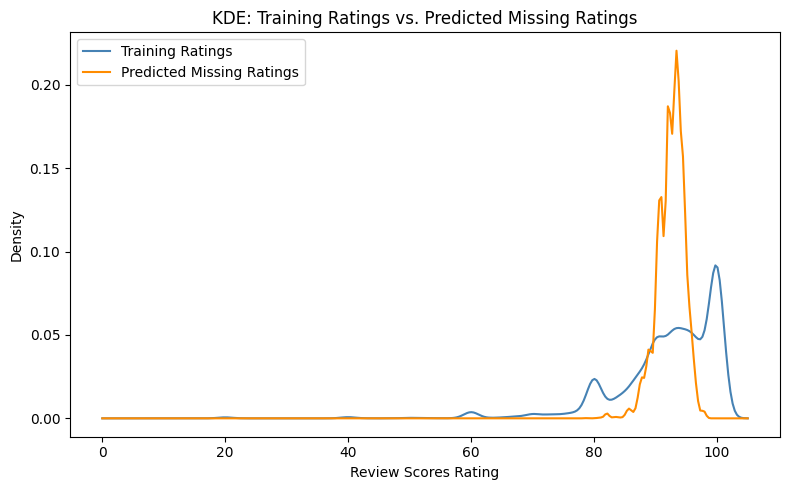

In [19]:
x_range = np.linspace(0, 105, 300)

kde_train = gaussian_kde(y)
kde_pred = gaussian_kde(predicted_ratings)

plt.figure(figsize=(8, 5))
plt.plot(x_range, kde_train(x_range), label='Training Ratings', color='steelblue')
plt.plot(x_range, kde_pred(x_range), label='Predicted Missing Ratings', color='darkorange')
plt.xlabel('Review Scores Rating')
plt.ylabel('Density')
plt.title('KDE: Training Ratings vs. Predicted Missing Ratings')
plt.legend()
plt.tight_layout()
plt.show()

The two distributions are similar in that both are concentrated in the high rating range (roughly 80–100), which makes sense since Airbnb listings tend to receive high reviews. However, there are notable differences. The training ratings (blue) are more spread out, with a longer left tail extending down to ratings as low as 20–40, and two visible bumps around 80 and 100. The predicted missing ratings (orange) are far more compressed, almost entirely concentrated between 88 and 96, with very sharp, narrow peaks and virtually no mass below 85.
This compression is a direct consequence of how kNN regression works, in that each prediction is an average of k=28 neighbors, which smooths out extreme values. The model cannot predict very low or very high ratings because averaging pulls everything toward the center of the training distribution. This means our imputed values likely underrepresent the true variability of the missing ratings. This means that listings with poor or exceptional ratings would get regressed toward the middle.